# Clustering de Perfiles Estudiantiles v2 — TEC21 vs Pre-TEC21

Aplica **K-Means (K = 4)** de forma independiente sobre Pre-TEC21 y TEC21 usando `dataset.csv` (143 k registros).

### Contenido
1. Selección de K — Codo · Silhouette · Davies-Bouldin · tamaño mínimo
2. Métricas de calidad (Silhouette + DB) globales y por cluster
3. Heatmap de perfiles z-score (snippet de referencia)
4. **Valores reales** por cluster en escala original
5. **Interpretación narrativa** de cada cluster
6. **Matching** Pre-TEC21 ↔ TEC21 con similitud coseno + algoritmo húngaro

### Features utilizadas
`PNA · scholarship.perc · loan.perc · english.evaluation · socioeconomic.level · social.lag · first.generation · parents.exatec`

## 0. Importaciones y configuración

In [17]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cosine

plt.rcParams.update({'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.dpi': 110})

SEED = 42
K    = 4
np.random.seed(SEED)
print('Librerías cargadas ✓')

Librerías cargadas ✓


## 1. Carga del dataset y separación por modelo educativo

In [18]:
df = pd.read_csv('../data/dataset.csv')
df['dropout'] = 1 - df['retention']

pre_df = df[df['educational.model'] == 0].copy().reset_index(drop=True)
tec_df = df[df['educational.model'] == 1].copy().reset_index(drop=True)

print(f'Total:      {len(df):>8,}  |  dropout global: {df["dropout"].mean()*100:.2f}%')
print(f'Pre-TEC21:  {len(pre_df):>8,}  |  dropout:        {pre_df["dropout"].mean()*100:.2f}%')
print(f'TEC21:      {len(tec_df):>8,}  |  dropout:        {tec_df["dropout"].mean()*100:.2f}%')
df.head(2)

Total:       143,326  |  dropout global: 8.12%
Pre-TEC21:    99,534  |  dropout:        8.39%
TEC21:        43,792  |  dropout:        7.50%


,student.id,generation,educational.model,level,gender,age,max.degree.parents,father.education.complete,father.education.summary,mother.education.complete,...,physical.education,cultural.diffusion,student.society,total.life.activities,athletic.sports,art.culture,student.society.leadership,life.work.mentoring,wellness.activities,dropout
0,1,AD15,0,High School,Male,15,No information,No information,No information,No information,...,No information,No information,No information,Does not apply,Does not apply,Does not apply,Does not apply,Does not apply,Does not apply,1
1,2,AD14,0,Undergraduate,Male,19,No information,No information,No information,No information,...,0,0,0,Does not apply,Does not apply,Does not apply,Does not apply,Does not apply,Does not apply,0


## 2. Definición de features, etiquetas y paleta

In [19]:
palette_cluster = ['#028090', '#e0479e', '#ed7d3a', '#cc3363']

key_features = [
    'PNA', 'scholarship.perc', 'loan.perc',
    'english.evaluation', 'socioeconomic.level', 'social.lag',
    'first.generation', 'parents.exatec'
]

labels = {
    'PNA':                 'PNA',
    'scholarship.perc':    'Beca (%)',
    'loan.perc':           'Préstamo (%)',
    'english.evaluation':  'Eval. Inglés',
    'socioeconomic.level': 'NSE',
    'social.lag':          'Rezago Social',
    'first.generation':    '1ª Generación',
    'parents.exatec':      'Padres EXATEC'
}

# Features numéricas compartidas entre ambos grupos (usadas para el matching)
shared_num = ['PNA', 'scholarship.perc', 'loan.perc', 'english.evaluation']

available_features = [f for f in key_features if f in df.columns]
print(f'Features disponibles: {len(available_features)} / {len(key_features)}')
print('Categóricas:', [f for f in available_features if df[f].dtype == object])

Features disponibles: 8 / 8
Categóricas: ['socioeconomic.level', 'social.lag', 'first.generation', 'parents.exatec']


## 3. Preprocesamiento

In [20]:
def preprocess_for_clustering(subset):
    """Codifica ordinalmente las categóricas, imputa NaN y escala con z-score."""
    avail = [f for f in key_features if f in subset.columns]
    X = subset[avail].copy()
    cat_cols = [c for c in avail if X[c].dtype == object]
    if cat_cols:
        enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X[cat_cols] = enc.fit_transform(X[cat_cols].fillna('Unknown'))
    for c in X.select_dtypes(['float64', 'int64']).columns:
        X[c] = X[c].fillna(X[c].median())
    return StandardScaler().fit_transform(X), subset['dropout'].values


X_pre, y_pre = preprocess_for_clustering(pre_df)
X_tec, y_tec = preprocess_for_clustering(tec_df)

print(f'X_pre: {X_pre.shape}  |  dropout Pre-TEC21: {y_pre.mean()*100:.2f}%')
print(f'X_tec: {X_tec.shape}  |  dropout TEC21:     {y_tec.mean()*100:.2f}%')

X_pre: (99534, 8)  |  dropout Pre-TEC21: 8.39%
X_tec: (43792, 8)  |  dropout TEC21:     7.50%


## 4. Selección de K — Codo · Silhouette · Davies-Bouldin · Tamaño mínimo

In [21]:
K_RANGE = range(2, 9)

def compute_k_metrics(X, sample_n=8000):
    """Calcula inercia, Silhouette, Davies-Bouldin y % del cluster más pequeño para K=2..8."""
    idx = np.random.choice(len(X), min(sample_n, len(X)), replace=False)
    X_s = X[idx]
    inertias, sils, dbs, min_pcts = [], [], [], []
    for k in K_RANGE:
        km  = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        lbl = km.fit_predict(X)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(X_s, lbl[idx]))
        dbs.append(davies_bouldin_score(X_s, lbl[idx]))
        min_pcts.append(min((lbl == c).sum() / len(X) * 100 for c in range(k)))
    return inertias, sils, dbs, min_pcts

print('Calculando métricas Pre-TEC21...')
in_pre, sil_pre_k, db_pre_k, minp_pre = compute_k_metrics(X_pre)
print('Calculando métricas TEC21...')
in_tec, sil_tec_k, db_tec_k, minp_tec = compute_k_metrics(X_tec)
print('Listo ✓')

Calculando métricas Pre-TEC21...
Calculando métricas TEC21...
Listo ✓


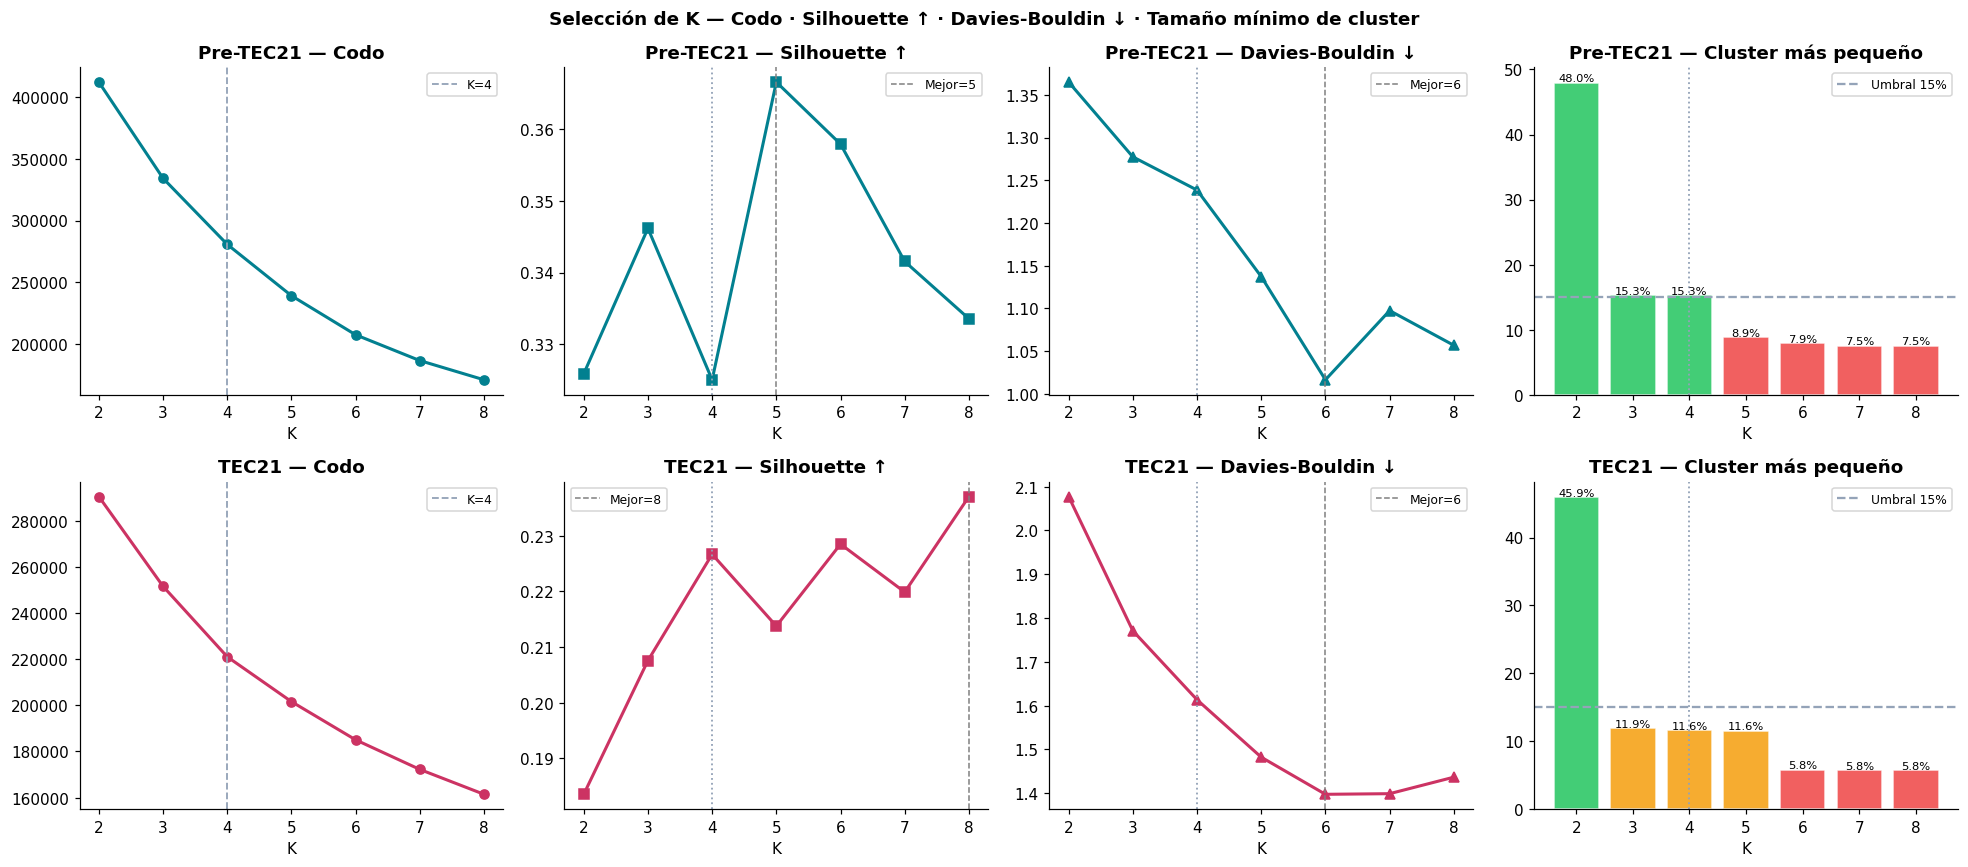

In [22]:
ks = list(K_RANGE)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(
    'Selección de K — Codo · Silhouette ↑ · Davies-Bouldin ↓ · Tamaño mínimo de cluster',
    fontweight='bold', fontsize=12)

configs = [
    (axes[0], in_pre, sil_pre_k, db_pre_k, minp_pre, 'Pre-TEC21', '#028090'),
    (axes[1], in_tec, sil_tec_k, db_tec_k, minp_tec, 'TEC21',     '#cc3363'),
]

for row_ax, iner, sils, dbs, minps, title, color in configs:
    ax_e, ax_s, ax_d, ax_m = row_ax

    ax_e.plot(ks, iner, 'o-', color=color, lw=2, ms=6)
    ax_e.axvline(K, color='#94a3b8', ls='--', lw=1.2, label=f'K={K}')
    ax_e.set_title(f'{title} — Codo', fontweight='bold'); ax_e.set_xlabel('K')
    ax_e.set_xticks(ks); ax_e.legend(fontsize=8)

    best_s = ks[np.argmax(sils)]
    ax_s.plot(ks, sils, 's-', color=color, lw=2, ms=6)
    ax_s.axvline(best_s, color='gray', ls='--', lw=1, label=f'Mejor={best_s}')
    ax_s.axvline(K, color='#94a3b8', ls=':', lw=1.2)
    ax_s.set_title(f'{title} — Silhouette ↑', fontweight='bold'); ax_s.set_xlabel('K')
    ax_s.set_xticks(ks); ax_s.legend(fontsize=8)

    best_d = ks[np.argmin(dbs)]
    ax_d.plot(ks, dbs, '^-', color=color, lw=2, ms=6)
    ax_d.axvline(best_d, color='gray', ls='--', lw=1, label=f'Mejor={best_d}')
    ax_d.axvline(K, color='#94a3b8', ls=':', lw=1.2)
    ax_d.set_title(f'{title} — Davies-Bouldin ↓', fontweight='bold'); ax_d.set_xlabel('K')
    ax_d.set_xticks(ks); ax_d.legend(fontsize=8)

    bar_colors = ['#22c55e' if p >= 15 else '#f59e0b' if p >= 10 else '#ef4444'
                  for p in minps]
    ax_m.bar(ks, minps, color=bar_colors, alpha=0.85, edgecolor='white')
    ax_m.axhline(15, color='#94a3b8', ls='--', lw=1.5, label='Umbral 15%')
    ax_m.axvline(K, color='#94a3b8', ls=':', lw=1.2)
    for x_pos, p in zip(ks, minps):
        ax_m.text(x_pos, p + 0.2, f'{p:.1f}%', ha='center', fontsize=7.5)
    ax_m.set_title(f'{title} — Cluster más pequeño', fontweight='bold')
    ax_m.set_xlabel('K'); ax_m.set_xticks(ks); ax_m.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/v2_seleccion_k.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Ajuste K-Means (K = 4)

In [23]:
def reorder_by_dropout(lbl, y):
    """Re-etiqueta clusters de menor a mayor tasa de deserción (C0 = menor riesgo)."""
    order   = sorted(np.unique(lbl), key=lambda k: y[lbl == k].mean())
    mapping = {old: new for new, old in enumerate(order)}
    return np.array([mapping[l] for l in lbl])


km_pre  = KMeans(n_clusters=K, random_state=SEED, n_init=20).fit(X_pre)
lbl_pre = reorder_by_dropout(km_pre.labels_, y_pre)

km_tec  = KMeans(n_clusters=K, random_state=SEED, n_init=20).fit(X_tec)
lbl_tec = reorder_by_dropout(km_tec.labels_, y_tec)

pre_df['cluster'] = lbl_pre
tec_df['cluster'] = lbl_tec

for name, X, y, lbl in [('Pre-TEC21', X_pre, y_pre, lbl_pre),
                         ('TEC21',     X_tec, y_tec, lbl_tec)]:
    n = len(X)
    print(f'\n{name}  (N={n:,}):')
    for k in range(K):
        mask = lbl == k
        print(f'  C{k}: n={mask.sum():>7,}  ({mask.sum()/n*100:.1f}%)  '
              f'dropout={y[mask].mean()*100:.1f}%')


Pre-TEC21  (N=99,534):
  C0: n= 19,867  (20.0%)  dropout=4.4%
  C1: n= 15,207  (15.3%)  dropout=7.7%
  C2: n= 33,502  (33.7%)  dropout=9.4%
  C3: n= 30,958  (31.1%)  dropout=10.2%

TEC21  (N=43,792):
  C0: n=  8,514  (19.4%)  dropout=5.5%
  C1: n=  5,081  (11.6%)  dropout=6.5%
  C2: n= 15,858  (36.2%)  dropout=7.9%
  C3: n= 14,339  (32.7%)  dropout=8.6%


## 6. Métricas de calidad — Silhouette y Davies-Bouldin

In [24]:
# ── Scores globales ────────────────────────────────────────────────────────
db_pre_k4  = davies_bouldin_score(X_pre, lbl_pre)
db_tec_k4  = davies_bouldin_score(X_tec, lbl_tec)

idx_sp = np.random.choice(len(X_pre), 8000, replace=False)
idx_st = np.random.choice(len(X_tec), 8000, replace=False)
sil_pre_k4 = silhouette_score(X_pre[idx_sp], lbl_pre[idx_sp])
sil_tec_k4 = silhouette_score(X_tec[idx_st], lbl_tec[idx_st])

# ── DB por cluster ─────────────────────────────────────────────────────────
def db_per_cluster(X, labels):
    k_vals    = np.unique(labels)
    centroids = np.array([X[labels == k].mean(axis=0) for k in k_vals])
    s         = np.array([X[labels == k].std() for k in k_vals])
    D         = euclidean_distances(centroids)
    scores = []
    for i in k_vals:
        r = [(s[i] + s[j]) / D[i, j] for j in k_vals if j != i and D[i, j] > 0]
        scores.append(max(r) if r else 0.0)
    return np.array(scores)

db_c_pre = db_per_cluster(X_pre, lbl_pre)
db_c_tec = db_per_cluster(X_tec, lbl_tec)

# ── Silhouette por cluster ─────────────────────────────────────────────────
sil_s_pre = silhouette_samples(X_pre[idx_sp], lbl_pre[idx_sp])
sil_s_tec = silhouette_samples(X_tec[idx_st], lbl_tec[idx_st])
sil_c_pre = [sil_s_pre[lbl_pre[idx_sp] == k].mean() for k in range(K)]
sil_c_tec = [sil_s_tec[lbl_tec[idx_st] == k].mean() for k in range(K)]

# ── Tabla resumen ──────────────────────────────────────────────────────────
rows = []
for k in range(K):
    rows.append({
        'Cluster':         f'C{k}',
        'n Pre':           int((lbl_pre == k).sum()),
        '% Pre':           round((lbl_pre == k).sum() / len(X_pre) * 100, 1),
        'Dropout Pre (%)': round(y_pre[lbl_pre == k].mean() * 100, 1),
        'Sil Pre':         round(sil_c_pre[k], 4),
        'DB Pre':          round(db_c_pre[k], 4),
        'n TEC':           int((lbl_tec == k).sum()),
        '% TEC':           round((lbl_tec == k).sum() / len(X_tec) * 100, 1),
        'Dropout TEC (%)': round(y_tec[lbl_tec == k].mean() * 100, 1),
        'Sil TEC':         round(sil_c_tec[k], 4),
        'DB TEC':          round(db_c_tec[k], 4),
    })

print(f'Pre-TEC21  Silhouette={sil_pre_k4:.4f}  Davies-Bouldin={db_pre_k4:.4f}')
print(f'TEC21      Silhouette={sil_tec_k4:.4f}  Davies-Bouldin={db_tec_k4:.4f}')
print()
display(pd.DataFrame(rows).set_index('Cluster'))

Pre-TEC21  Silhouette=0.3236  Davies-Bouldin=1.2424
TEC21      Silhouette=0.2278  Davies-Bouldin=1.6090



,n Pre,% Pre,Dropout Pre (%),Sil Pre,DB Pre,n TEC,% TEC,Dropout TEC (%),Sil TEC,DB TEC
Cluster,,,,,,,,,,
C0,19867,20.0,4.4,0.1313,0.6653,8514,19.4,5.5,0.2022,0.7080
C1,15207,15.3,7.7,0.3301,0.6062,5081,11.6,6.5,0.2007,0.6385
C2,33502,33.7,9.4,0.4050,0.6653,15858,36.2,7.9,0.1794,0.7410
C3,30958,31.1,10.2,0.3487,0.6062,14339,32.7,8.6,0.3037,0.7410


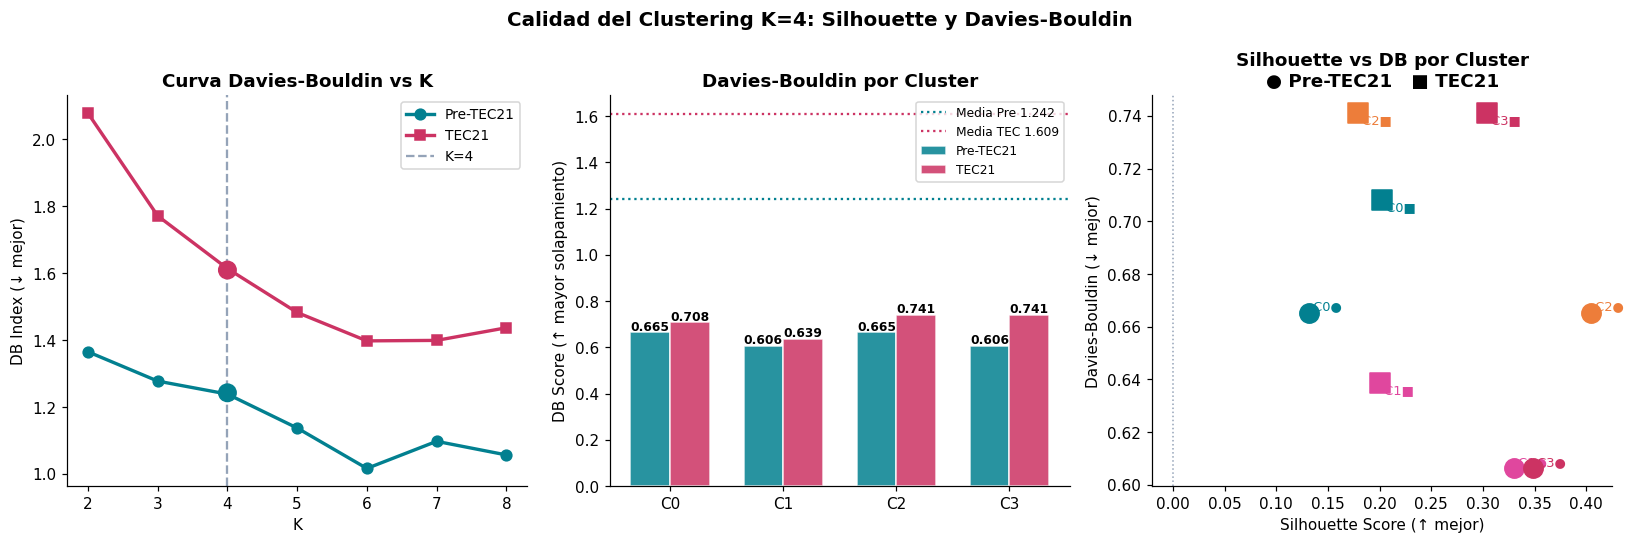

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Calidad del Clustering K=4: Silhouette y Davies-Bouldin',
             fontweight='bold', fontsize=13)

# Panel 1: curva DB(K)
axes[0].plot(ks, db_pre_k, 'o-', color='#028090', lw=2.2, ms=7, label='Pre-TEC21')
axes[0].plot(ks, db_tec_k, 's-', color='#cc3363', lw=2.2, ms=7, label='TEC21')
axes[0].axvline(K, color='#94a3b8', ls='--', lw=1.5, label=f'K={K}')
axes[0].scatter([K, K], [db_pre_k4, db_tec_k4],
                color=['#028090', '#cc3363'], s=130, zorder=5)
axes[0].set_xlabel('K'); axes[0].set_ylabel('DB Index (↓ mejor)')
axes[0].set_title('Curva Davies-Bouldin vs K', fontweight='bold')
axes[0].set_xticks(ks); axes[0].legend(fontsize=9)

# Panel 2: DB por cluster
x = np.arange(K); w = 0.35
b1 = axes[1].bar(x - w/2, db_c_pre, w, color='#028090', alpha=0.85,
                 edgecolor='white', label='Pre-TEC21')
b2 = axes[1].bar(x + w/2, db_c_tec, w, color='#cc3363', alpha=0.85,
                 edgecolor='white', label='TEC21')
for bars in [b1, b2]:
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')
axes[1].axhline(db_pre_k4, color='#028090', ls=':', lw=1.5,
                label=f'Media Pre {db_pre_k4:.3f}')
axes[1].axhline(db_tec_k4, color='#cc3363', ls=':', lw=1.5,
                label=f'Media TEC {db_tec_k4:.3f}')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'C{k}' for k in range(K)])
axes[1].set_ylabel('DB Score (↑ mayor solapamiento)')
axes[1].set_title('Davies-Bouldin por Cluster', fontweight='bold')
axes[1].legend(fontsize=8)

# Panel 3: Silhouette vs DB scatter
for k in range(K):
    axes[2].scatter(sil_c_pre[k], db_c_pre[k],
                    color=palette_cluster[k], s=160, marker='o', zorder=5)
    axes[2].scatter(sil_c_tec[k], db_c_tec[k],
                    color=palette_cluster[k], s=160, marker='s', zorder=5)
    axes[2].annotate(f' C{k}●', (sil_c_pre[k], db_c_pre[k]),
                     fontsize=8.5, color=palette_cluster[k], va='bottom')
    axes[2].annotate(f' C{k}■', (sil_c_tec[k], db_c_tec[k]),
                     fontsize=8.5, color=palette_cluster[k], va='top')
axes[2].axvline(0, color='#94a3b8', ls=':', lw=1)
axes[2].set_xlabel('Silhouette Score (↑ mejor)')
axes[2].set_ylabel('Davies-Bouldin (↓ mejor)')
axes[2].set_title('Silhouette vs DB por Cluster\n● Pre-TEC21   ■ TEC21',
                   fontweight='bold')

plt.tight_layout()
plt.savefig('../data/v2_metricas_silhouette_db.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Silhouette plot por cluster (diagrama de cuchillo)

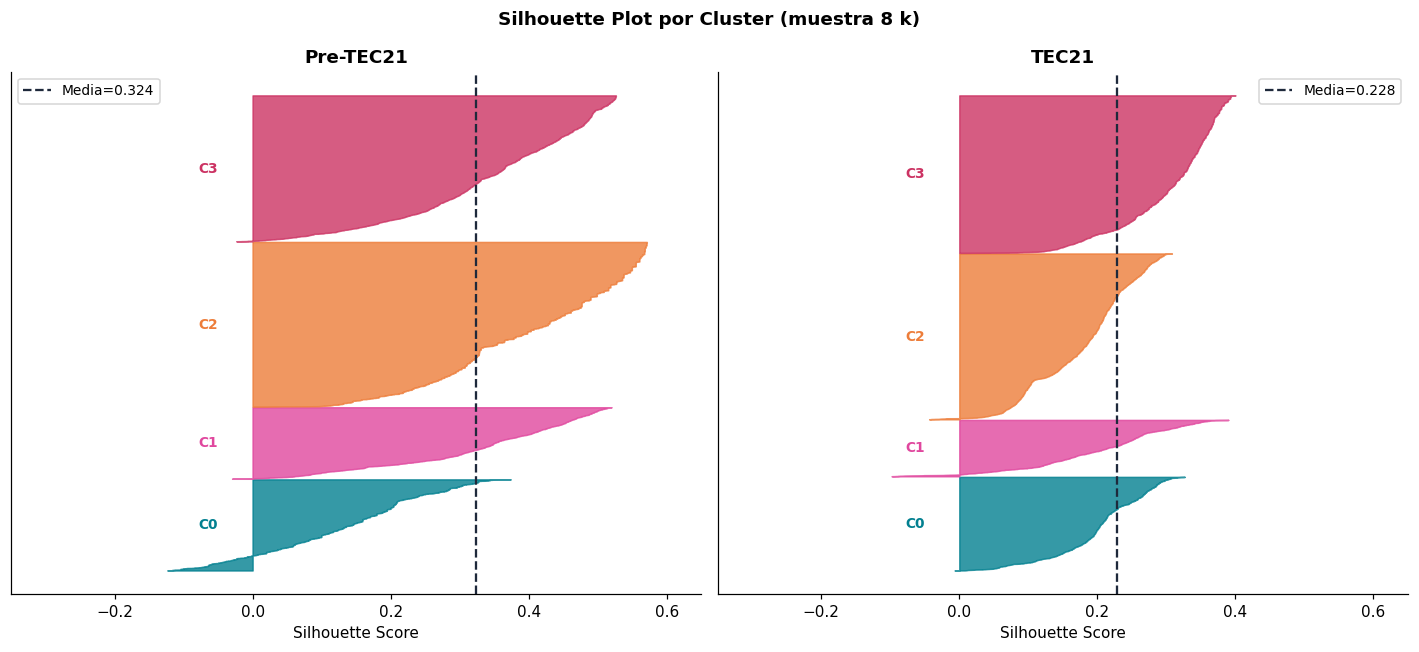

In [26]:
def silhouette_plot(X, labels, sil_samples, title, ax, global_sil):
    y_lower = 10
    for k in range(K):
        k_vals  = np.sort(sil_samples[labels == k])
        y_upper = y_lower + len(k_vals)
        c       = palette_cluster[k]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, k_vals,
                         facecolor=c, edgecolor=c, alpha=0.8)
        ax.text(-0.05, (y_lower + y_upper) / 2, f'C{k}',
                fontsize=9, ha='right', va='center',
                fontweight='bold', color=c)
        y_lower = y_upper + 10
    ax.axvline(global_sil, color='#1e293b', ls='--', lw=1.5,
               label=f'Media={global_sil:.3f}')
    ax.set_xlabel('Silhouette Score')
    ax.set_title(title, fontweight='bold')
    ax.set_yticks([]); ax.set_xlim(-0.35, 0.65); ax.legend(fontsize=9)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Silhouette Plot por Cluster (muestra 8 k)', fontweight='bold', fontsize=12)

silhouette_plot(X_pre[idx_sp], lbl_pre[idx_sp], sil_s_pre, 'Pre-TEC21', ax1, sil_pre_k4)
silhouette_plot(X_tec[idx_st], lbl_tec[idx_st], sil_s_tec, 'TEC21',     ax2, sil_tec_k4)

plt.tight_layout()
plt.savefig('../data/v2_silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Heatmap de perfiles — Z-scores

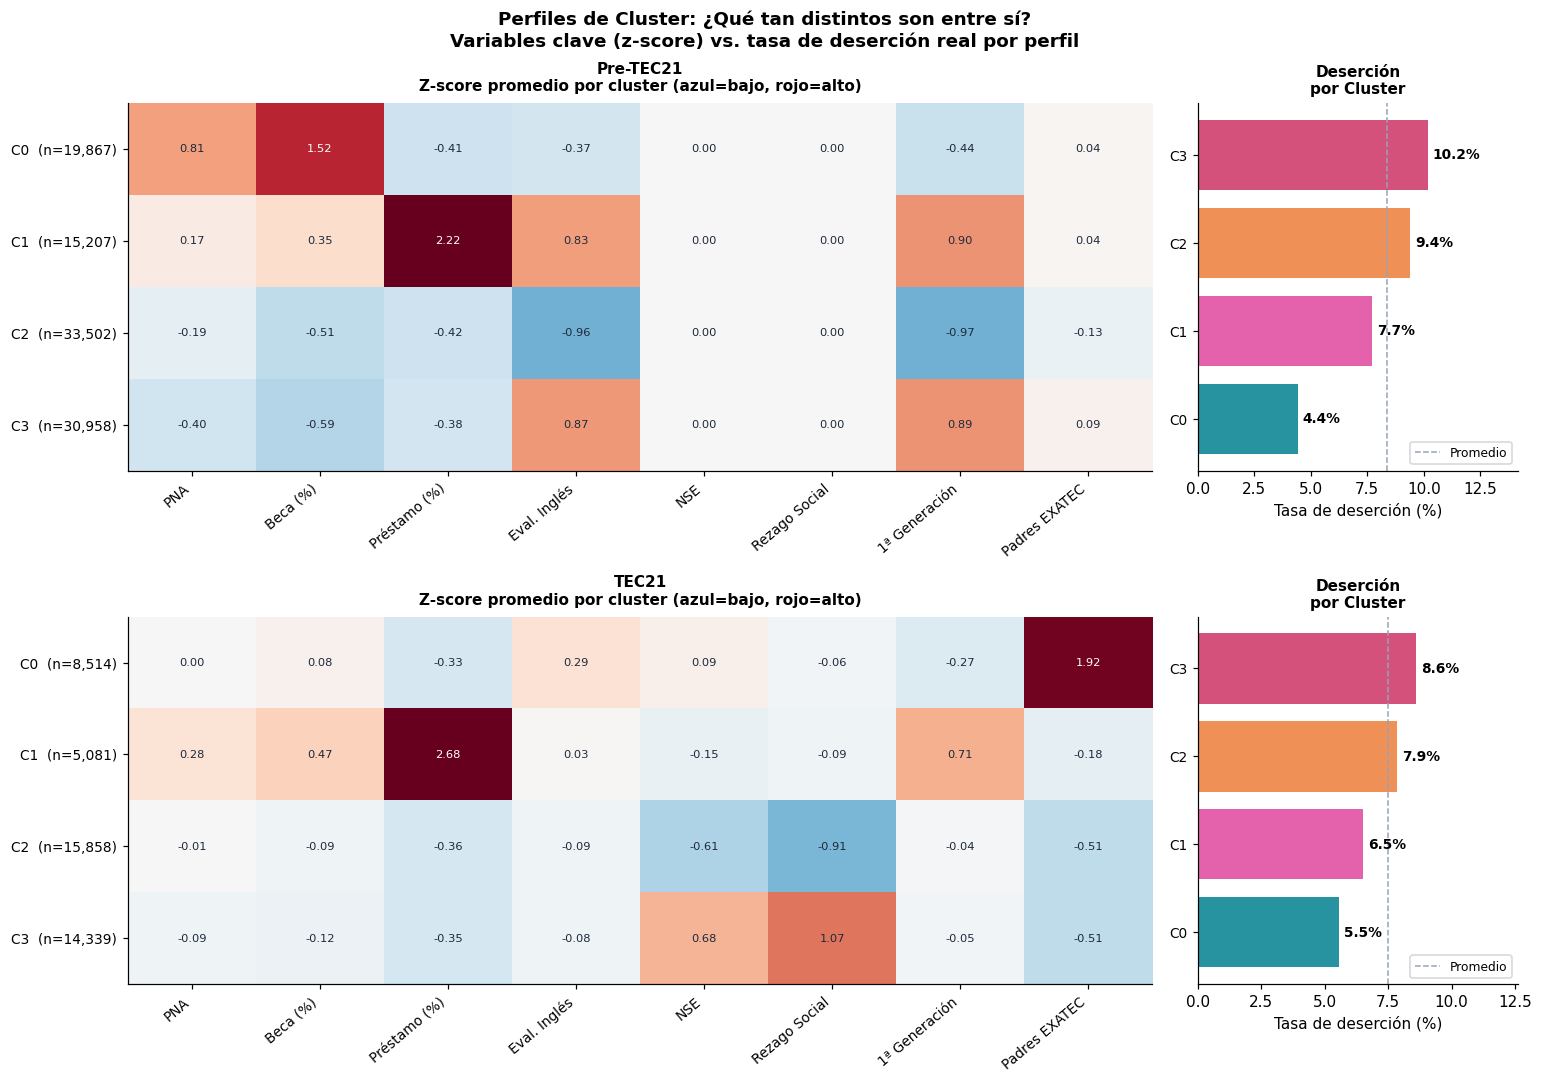

In [27]:
def build_profile_df(subset, cluster_labels_array, y_out):
    available = [f for f in key_features if f in subset.columns]
    data = subset[available + ['dropout']].copy()
    cat_cols = [c for c in available if data[c].dtype == object]
    if cat_cols:
        enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        data[cat_cols] = enc.fit_transform(data[cat_cols].fillna('Unknown'))
    for c in [c for c in available if data[c].dtype in ['float64','int64']]:
        data[c] = data[c].fillna(data[c].median())
    data[available] = StandardScaler().fit_transform(data[available])
    data['cluster']  = cluster_labels_array
    profile          = data.groupby('cluster')[available].mean()
    profile.columns  = [labels.get(c, c) for c in profile.columns]
    dropout_rates, sizes = [], []
    for k in range(K):
        mask = cluster_labels_array == k
        dropout_rates.append(y_out[mask].mean() * 100)
        sizes.append(mask.sum())
    profile['Deserción (%)'] = dropout_rates
    profile['n']             = sizes
    return profile


prof_pre = build_profile_df(pre_df.drop(columns=['cluster']), lbl_pre, y_pre)
prof_tec = build_profile_df(tec_df.drop(columns=['cluster']), lbl_tec, y_tec)


def plot_profile_heatmap(ax_heat, ax_bar, profile, title, palette, global_dr):
    feat_cols = [c for c in profile.columns if c not in ['Deserción (%)', 'n']]
    heat_data = profile[feat_cols].values
    ax_heat.imshow(heat_data, aspect='auto', cmap='RdBu_r',
                   vmin=-2, vmax=2, interpolation='nearest')
    ax_heat.set_xticks(range(len(feat_cols)))
    ax_heat.set_xticklabels(feat_cols, rotation=40, ha='right', fontsize=9)
    ax_heat.set_yticks(range(K))
    ax_heat.set_yticklabels(
        [f'C{k}  (n={profile["n"].iloc[k]:,})' for k in range(K)], fontsize=9)
    for i in range(K):
        for j in range(len(feat_cols)):
            v = heat_data[i, j]
            ax_heat.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7.5,
                         color='white' if abs(v) > 1.2 else '#1e293b')
    ax_heat.set_title(
        f'{title}\nZ-score promedio por cluster (azul=bajo, rojo=alto)',
        fontweight='bold', fontsize=10, pad=8)
    bars = ax_bar.barh(range(K), profile['Deserción (%)'], color=palette, alpha=0.85)
    for bar, rate in zip(bars, profile['Deserción (%)']):
        ax_bar.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                    f'{rate:.1f}%', va='center', fontsize=9, fontweight='bold')
    ax_bar.set_yticks(range(K))
    ax_bar.set_yticklabels([f'C{k}' for k in range(K)], fontsize=9)
    ax_bar.set_xlabel('Tasa de deserción (%)')
    ax_bar.set_title('Deserción\npor Cluster', fontweight='bold', fontsize=10)
    ax_bar.set_xlim(0, profile['Deserción (%)'].max() + 4)
    ax_bar.axvline(global_dr, color='#94a3b8', linestyle='--', linewidth=1, label='Promedio')
    ax_bar.legend(fontsize=8)


fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                          gridspec_kw={'width_ratios': [3.2, 1]})
fig.suptitle(
    'Perfiles de Cluster: ¿Qué tan distintos son entre sí?\n'
    'Variables clave (z-score) vs. tasa de deserción real por perfil',
    fontweight='bold', fontsize=12)

plot_profile_heatmap(axes[0,0], axes[0,1], prof_pre,
                     'Pre-TEC21', palette_cluster, y_pre.mean()*100)
plot_profile_heatmap(axes[1,0], axes[1,1], prof_tec,
                     'TEC21',     palette_cluster, y_tec.mean()*100)

plt.tight_layout()
plt.savefig('../data/v2_clustering_perfiles_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Valores reales por cluster

Medias en la **escala original** de cada variable (sin z-score), desglosadas por cluster.

In [28]:
# ── Numéricas: medias reales ───────────────────────────────────────────────
num_raw = ['PNA', 'scholarship.perc', 'loan.perc', 'english.evaluation']

def raw_means_table(sub, lbl, y):
    t = sub.groupby('cluster')[num_raw + ['dropout']].mean().copy()
    t.index = [f'C{k}' for k in t.index]
    t.rename(columns={'scholarship.perc': 'Beca (%)',
                       'loan.perc':        'Préstamo (%)',
                       'english.evaluation':'Eval. Inglés',
                       'dropout':           'Dropout (%)'}, inplace=True)
    t['Beca (%)']     = (t['Beca (%)']     * 100).round(1)
    t['Préstamo (%)'] = (t['Préstamo (%)'] * 100).round(1)
    t['Dropout (%)']  = (t['Dropout (%)']  * 100).round(1)
    t['PNA']          = t['PNA'].round(1)
    t['Eval. Inglés'] = t['Eval. Inglés'].round(2)
    n_total = len(sub)
    t.insert(0, 'n',   [(lbl == k).sum() for k in range(K)])
    t.insert(1, '% grupo', [round((lbl==k).sum()/n_total*100,1) for k in range(K)])
    return t

raw_pre = raw_means_table(pre_df, lbl_pre, y_pre)
raw_tec = raw_means_table(tec_df, lbl_tec, y_tec)

print('═══ Pre-TEC21 — Valores reales por cluster ═══')
display(raw_pre)
print('\n═══ TEC21 — Valores reales por cluster ═══')
display(raw_tec)

# ── Categóricas: distribución % ───────────────────────────────────────────
print('\n═══ TEC21 — Variables categóricas por cluster (%) ═══')
for cat in ['parents.exatec', 'socioeconomic.level', 'social.lag', 'first.generation']:
    ct = (pd.crosstab(tec_df['cluster'], tec_df[cat], normalize='index') * 100).round(1)
    ct.index = [f'C{k}' for k in ct.index]
    print(f'\n{cat}:')
    display(ct)

print('\n═══ Pre-TEC21 — Variables categóricas por cluster (%) ═══')
for cat in ['parents.exatec', 'first.generation']:
    ct = (pd.crosstab(pre_df['cluster'], pre_df[cat], normalize='index') * 100).round(1)
    ct.index = [f'C{k}' for k in ct.index]
    print(f'\n{cat}:')
    display(ct)

═══ Pre-TEC21 — Valores reales por cluster ═══


,n,% grupo,PNA,Beca (%),Préstamo (%),Eval. Inglés,Dropout (%)
C0,19867,20.0,93.0,51.9,0.1,1.70,4.4
C1,15207,15.3,89.0,24.8,24.9,5.16,7.7
C2,33502,33.7,86.8,4.9,0.0,0.02,9.4
C3,30958,31.1,85.4,3.1,0.4,5.26,10.2



═══ TEC21 — Valores reales por cluster ═══


,n,% grupo,PNA,Beca (%),Préstamo (%),Eval. Inglés,Dropout (%)
C0,8514,19.4,88.6,20.6,0.3,5.63,5.5
C1,5081,11.6,90.2,29.6,23.3,5.13,6.5
C2,15858,36.2,88.5,16.7,0.1,4.90,7.9
C3,14339,32.7,88.0,16.0,0.2,4.93,8.6



═══ TEC21 — Variables categóricas por cluster (%) ═══

parents.exatec:


...

first.generation,Does not apply,No,No information,Yes
C0,52.0,47.5,0.0,0.4
C1,0.0,86.4,0.2,13.3
C2,49.4,42.2,0.2,8.3
C3,49.0,43.2,0.1,7.7



═══ Pre-TEC21 — Variables categóricas por cluster (%) ═══

parents.exatec:


parents.exatec,No,No information,Yes
C0,63.3,15.0,21.7
C1,50.0,41.6,8.5
C2,72.0,10.3,17.7
C3,49.6,38.5,11.9



first.generation:


first.generation,Does not apply,No,No information,Yes
C0,68.7,10.5,20.4,0.4
C1,0.2,21.7,74.2,3.8
C2,98.0,1.9,0.1,0.0
C3,0.0,23.9,70.9,5.2


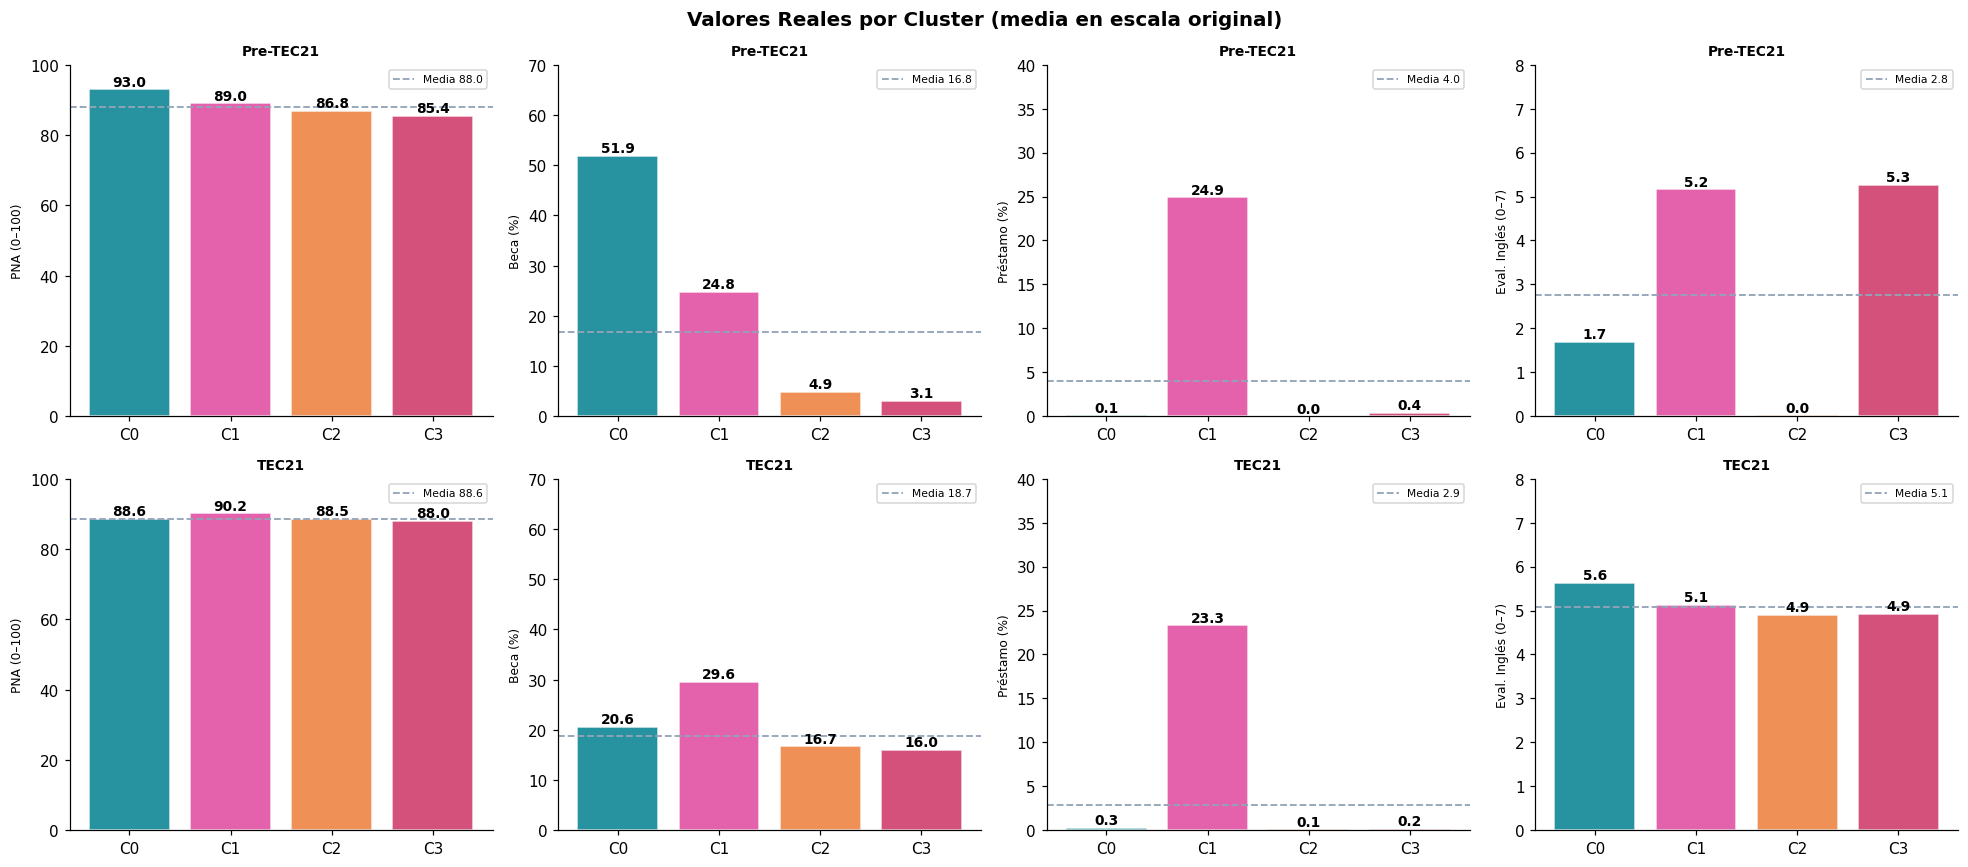

In [29]:
# ── Visualización: barras de medias reales ─────────────────────────────────
metric_configs = [
    ('PNA',          'PNA (0–100)',        0, 100,
     pre_df['PNA'].mean(), tec_df['PNA'].mean()),
    ('Beca (%)',      'Beca (%)',           0,  70,
     pre_df['scholarship.perc'].mean()*100, tec_df['scholarship.perc'].mean()*100),
    ('Préstamo (%)', 'Préstamo (%)',        0,  40,
     pre_df['loan.perc'].mean()*100, tec_df['loan.perc'].mean()*100),
    ('Eval. Inglés', 'Eval. Inglés (0–7)', 0,   8,
     pre_df['english.evaluation'].mean(), tec_df['english.evaluation'].mean()),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Valores Reales por Cluster (media en escala original)',
             fontweight='bold', fontsize=13)

cluster_ticks = [f'C{k}' for k in range(K)]

for col_idx, (col, ylabel, ymin, ymax, gm_pre, gm_tec) in enumerate(metric_configs):
    for row_idx, (raw_df, label, gm) in enumerate([
            (raw_pre, 'Pre-TEC21', gm_pre),
            (raw_tec, 'TEC21',     gm_tec)]):
        ax   = axes[row_idx, col_idx]
        vals = raw_df[col].values
        bars = ax.bar(cluster_ticks, vals,
                      color=palette_cluster, alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (ymax - ymin) * 0.01,
                    f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')
        ax.axhline(gm, color='#94a3b8', ls='--', lw=1.2,
                   label=f'Media {gm:.1f}')
        ax.set_ylim(ymin, ymax)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.set_title(label, fontweight='bold', fontsize=9)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('../data/v2_valores_reales.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Significado de cada cluster

### 10.1 Pre-TEC21
Los clusters Pre-TEC21 se diferencian principalmente por **beca, préstamo, inglés y PNA**. Las variables `NSE` y `Rezago Social` no están disponibles para este grupo.

---

#### 🔵 C0 — "Alta beca, PNA excelente" · 20.0 % · dropout **4.4 %** (mínimo)
| Variable | Valor medio |
|---|---|
| PNA | **93.0** (la más alta) |
| Beca | **52 %** (la más alta) |
| Préstamo | ~0 % |
| Eval. Inglés | 1.7 / 7 (bajo) |
| Padres EXATEC | 21.7 % Sí |
| 1ª Generación | 68.7 % No aplica |

El perfil más favorecido académica y económicamente. PNA top, máxima beca, padres EXATEC en 22 %. Inglés bajo porque proceden de Prepa Tec (exentos). La combinación de mérito académico + soporte institucional produce la menor deserción del grupo.

---

#### 🩷 C1 — "Préstamo y buen inglés" · 15.3 % · dropout 7.7 %
| Variable | Valor medio |
|---|---|
| PNA | 89.0 |
| Beca | 24.7 % |
| **Préstamo** | **24.9 %** (único con préstamo) |
| **Eval. Inglés** | **5.16 / 7** |
| Padres EXATEC | 8.5 % Sí |
| 1ª Generación | 74 % Sin info |

Único cluster con préstamo significativo. Combina beca + préstamo ≈ 50 % de apoyo financiero. Inglés alto. Primera generación con muchos datos faltantes (74 % sin info), lo que puede indicar un perfil de procedencia más diversa. Riesgo moderado: el soporte financiero activo protege pese a menor PNA.

---

#### 🟠 C2 — "Sin apoyo financiero, sin inglés" · 33.7 % · dropout 9.4 %
| Variable | Valor medio |
|---|---|
| PNA | 86.8 |
| Beca | 4.9 % (mínima) |
| Préstamo | ~0 % |
| **Eval. Inglés** | **~0 / 7** |
| Padres EXATEC | 17.7 % Sí |
| 1ª Generación | **98 % No aplica** |

Cluster mayoritario junto a C3. Inglés prácticamente nulo y mínima beca. "No aplica" en primera generación = continuidad familiar con el Tec (prepa tec probablemente), pero sin soporte financiero. La falta de recursos económicos combinada con una PNA media eleva el riesgo.

---

#### 🔴 C3 — "Sin apoyo financiero, inglés alto" · 31.1 % · dropout **10.2 %** (máximo)
| Variable | Valor medio |
|---|---|
| PNA | **85.5** (la más baja) |
| Beca | 3.1 % (mínima) |
| Préstamo | ~0 % |
| **Eval. Inglés** | **5.26 / 7** |
| 1ª Generación | 71 % Sin info |

Perfil de mayor riesgo. Tiene inglés alto (similar a C1) pero **sin préstamo ni beca significativa** y la PNA más baja. La comparación directa con C1 revela que el préstamo actúa como factor protector crítico: mismas capacidades idiomáticas, pero sin soporte económico estructurado la deserción sube 2.5 pp.

---

### 10.2 TEC21
Los clusters TEC21 se diferencian principalmente por **padres EXATEC, NSE y rezago social**. El inglés es alto en todos (≥ 4.9 / 7).

---

#### 🔵 C0 — "Heredero Tec" · 19.4 % · dropout **5.5 %** (mínimo)
| Variable | Valor medio |
|---|---|
| PNA | 88.6 |
| Beca | 20.6 % |
| Préstamo | 0.3 % |
| Eval. Inglés | **5.63 / 7** (el más alto) |
| **Padres EXATEC** | **99.7 % Sí** |
| NSE | 32 % Level 7 · 55 % Sin info |
| Rezago social | 55 % Bajo · 43 % Sin info |

Prácticamente el 100 % tiene padre o madre egresados del Tec. Inglés más alto de todos los clusters. Menor deserción absoluta (5.5 %). El **capital cultural familiar** — conocer el sistema, las redes y las expectativas — es el principal factor protector, independientemente del NSE registrado.

---

#### 🩷 C1 — "Préstamo y primera generación" · 11.6 % · dropout 6.5 %
| Variable | Valor medio |
|---|---|
| PNA | **90.2** (la más alta en TEC21) |
| Beca | **29.6 %** (la más alta) |
| **Préstamo** | **23.3 %** (único con préstamo) |
| Eval. Inglés | 5.13 / 7 |
| Padres EXATEC | 13.7 % Sí |
| **1ª Generación** | **13.3 % Sí** |

Cluster más pequeño (11.6 %). Única subpoblación en TEC21 con préstamo significativo, mayor beca y la PNA más alta. Primera generación presente (13 %), lo que explica el acceso a financiamiento como palanca de entrada. Bajo riesgo relativo gracias al soporte financiero activo.

---

#### 🟠 C2 — "NSE conocido, bajo rezago" · 36.2 % · dropout 7.9 %
| Variable | Valor medio |
|---|---|
| PNA | 88.5 |
| Beca | 16.7 % |
| Préstamo | 0.1 % |
| Eval. Inglés | 4.90 / 7 |
| **NSE** | **43.5 % Level 7** · 18.5 % Sin info |
| **Rezago social** | **96.4 % Bajo** |
| Padres EXATEC | 0.2 % Sí |

NSE Level 7 dominante y casi cero rezago social. Sin padres EXATEC pero con sólida base socioeconómica estructural. La estabilidad económica conocida protege de la deserción, aunque sin el capital cultural del C0 el riesgo es moderado.

---

#### 🔴 C3 — "Sin información socioeconómica" · 32.7 % · dropout **8.6 %** (máximo)
| Variable | Valor medio |
|---|---|
| PNA | 88.0 |
| Beca | 16.0 % |
| **NSE** | **100 % Sin información** |
| **Rezago social** | **98 % Sin información** |
| Padres EXATEC | 0 % Sí |

Toda la información socioeconómica es faltante. Mayor deserción en TEC21. La ausencia de datos no es aleatoria: puede reflejar estudiantes sin acceso a los registros, de zonas con menor cobertura de datos, o que no completaron el perfil socioeconómico. Sin el escudo de padres EXATEC ni datos de NSE que permitan identificar y activar apoyos tempranos.

## 11. Matching entre clusters Pre-TEC21 ↔ TEC21

**Metodología:** se computan z-scores de las 4 variables numéricas compartidas (`PNA`, `Beca`, `Préstamo`, `Eval. Inglés`) para cada centroide, luego se calcula la **similitud coseno** entre todos los pares Pre × TEC, y el **algoritmo húngaro** encuentra el emparejamiento óptimo 1-a-1 que maximiza la similitud total.

> Las variables categóricas (`NSE`, `Rezago Social`, `Padres EXATEC`, `1ª Generación`) se excluyen del matching porque en Pre-TEC21 son mayoritariamente "Sin información" y no aportan discriminación para la comparación entre grupos.

In [30]:
# ── Preprocesar solo features numéricas compartidas ────────────────────────
def preprocess_shared(subset):
    X = subset[shared_num].copy()
    for c in X.columns:
        X[c] = X[c].fillna(X[c].median())
    return StandardScaler().fit_transform(X)

Xs_pre = preprocess_shared(pre_df)
Xs_tec = preprocess_shared(tec_df)

# Centroides en espacio de features compartidas
centroids_pre = np.array([Xs_pre[lbl_pre == k].mean(axis=0) for k in range(K)])
centroids_tec = np.array([Xs_tec[lbl_tec == k].mean(axis=0) for k in range(K)])

# Matriz de similitud coseno K×K
sim_matrix = np.array([[1 - cosine(centroids_pre[i], centroids_tec[j])
                         for j in range(K)] for i in range(K)])

# Matching óptimo
row_ind, col_ind = linear_sum_assignment(-sim_matrix)
match_pairs = [(r, c, sim_matrix[r, c]) for r, c in zip(row_ind, col_ind)]

sim_df = pd.DataFrame(sim_matrix,
                       index   = [f'Pre-C{k}' for k in range(K)],
                       columns = [f'TEC-C{k}' for k in range(K)])
print('Similitud coseno (Pre filas × TEC columnas):')
display(sim_df.round(4))

print('\nMatching óptimo (algoritmo húngaro):')
for r, c, s in match_pairs:
    print(f'  Pre-C{r}  →  TEC-C{c}   (similitud = {s:.4f})')

Similitud coseno (Pre filas × TEC columnas):


,TEC-C0,TEC-C1,TEC-C2,TEC-C3
Pre-C0,0.1879,-0.0339,0.0620,-0.1108
Pre-C1,-0.4400,0.9411,-0.9899,-0.9637
Pre-C2,-0.3362,-0.4464,0.6355,0.6497
Pre-C3,0.6161,-0.4237,0.2410,0.3693



Matching óptimo (algoritmo húngaro):
  Pre-C0  →  TEC-C2   (similitud = 0.0620)
  Pre-C1  →  TEC-C1   (similitud = 0.9411)
  Pre-C2  →  TEC-C3   (similitud = 0.6497)
  Pre-C3  →  TEC-C0   (similitud = 0.6161)


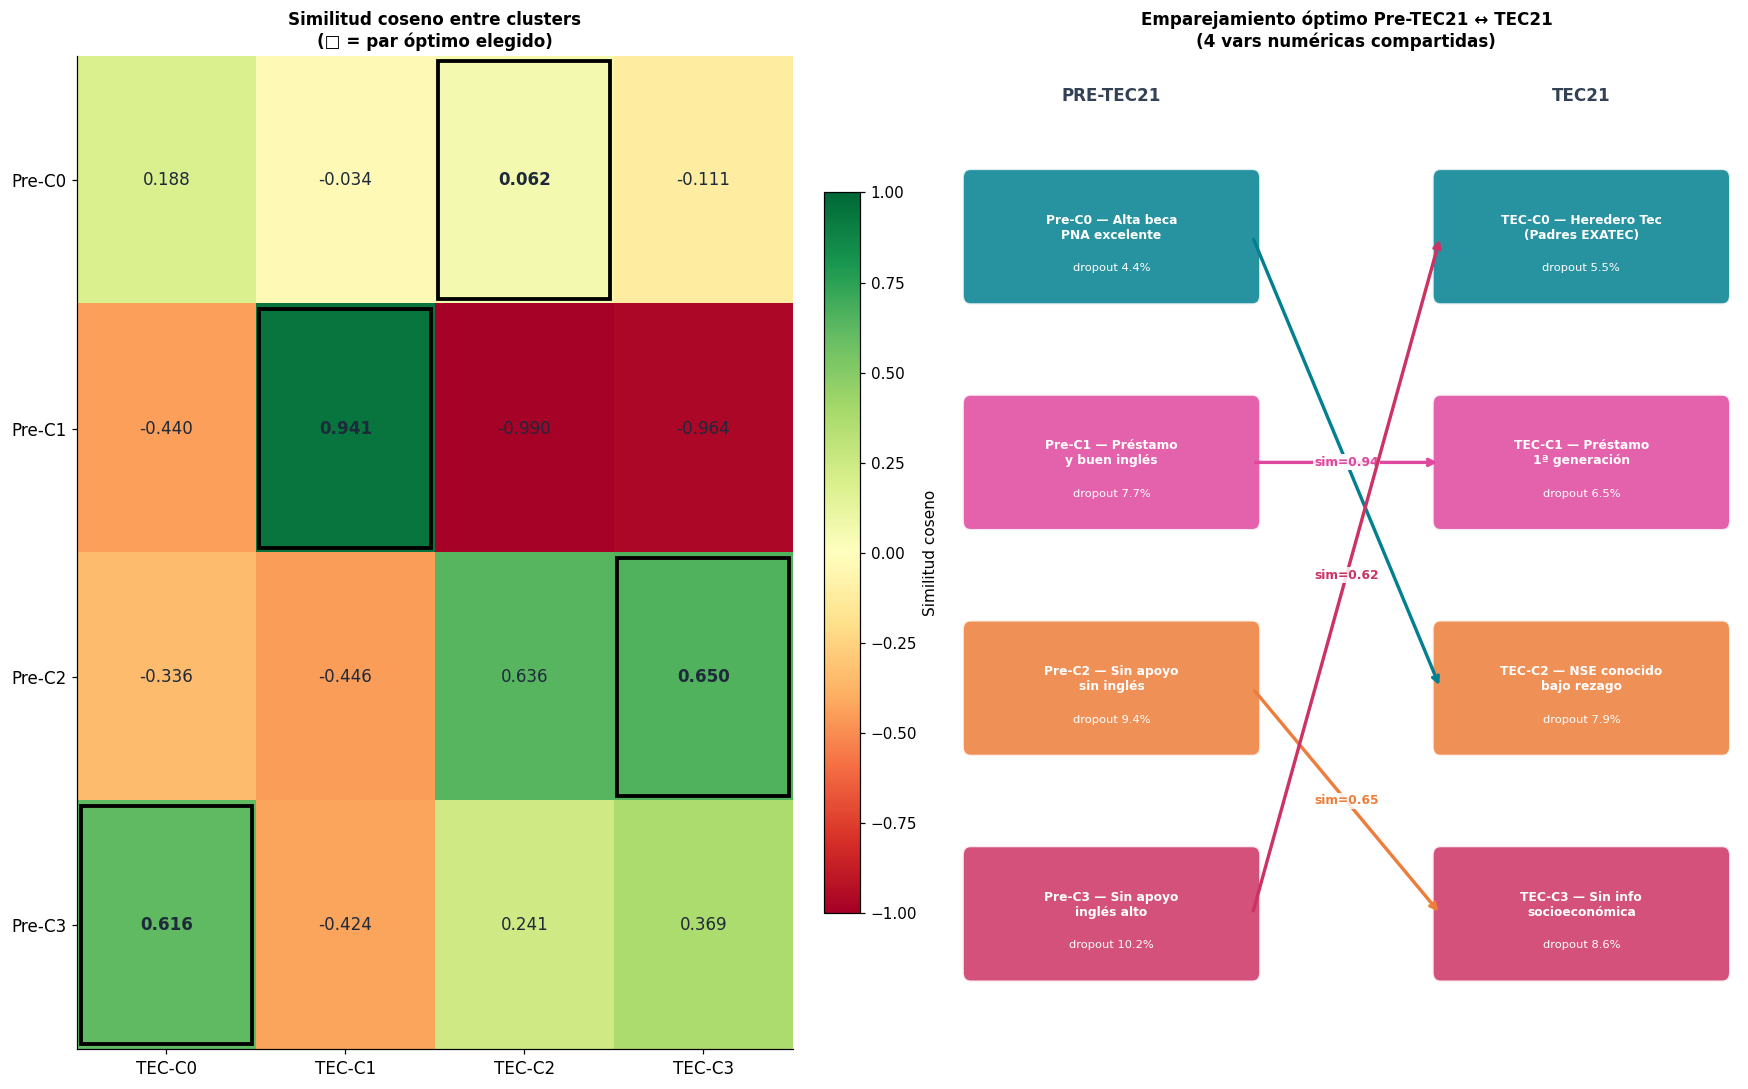

In [31]:
# ── Visualización del matching ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))

# ── Panel 1: heatmap similitud ─────────────────────────────────────────────
ax_heat = fig.add_subplot(1, 2, 1)
im = ax_heat.imshow(sim_matrix, cmap='RdYlGn', vmin=-1, vmax=1,
                    aspect='auto', interpolation='nearest')
plt.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04,
             label='Similitud coseno')
for i in range(K):
    for j in range(K):
        matched = any(r == i and c == j for r, c, _ in match_pairs)
        ax_heat.text(j, i, f'{sim_matrix[i,j]:.3f}',
                     ha='center', va='center', fontsize=11,
                     fontweight='bold' if matched else 'normal',
                     color='#1e293b')
        if matched:
            ax_heat.add_patch(
                plt.Rectangle((j - 0.48, i - 0.48), 0.96, 0.96,
                               fill=False, edgecolor='black', linewidth=2.5))
ax_heat.set_xticks(range(K))
ax_heat.set_xticklabels([f'TEC-C{k}' for k in range(K)], fontsize=11)
ax_heat.set_yticks(range(K))
ax_heat.set_yticklabels([f'Pre-C{k}' for k in range(K)], fontsize=11)
ax_heat.set_title('Similitud coseno entre clusters\n(□ = par óptimo elegido)',
                   fontweight='bold', fontsize=11)

# ── Panel 2: diagrama de flujo del matching ────────────────────────────────
ax_flow = fig.add_subplot(1, 2, 2)
ax_flow.set_xlim(0, 10); ax_flow.set_ylim(0, 11)
ax_flow.axis('off')
ax_flow.set_title(
    'Emparejamiento óptimo Pre-TEC21 ↔ TEC21\n(4 vars numéricas compartidas)',
    fontweight='bold', fontsize=11)

cluster_names_pre = [
    'C0 — Alta beca\nPNA excelente',
    'C1 — Préstamo\ny buen inglés',
    'C2 — Sin apoyo\nsin inglés',
    'C3 — Sin apoyo\ninglés alto',
]
cluster_names_tec = [
    'C0 — Heredero Tec\n(Padres EXATEC)',
    'C1 — Préstamo\n1ª generación',
    'C2 — NSE conocido\nbajo rezago',
    'C3 — Sin info\nsocioeconómica',
]
dropout_pre = [y_pre[lbl_pre == k].mean() * 100 for k in range(K)]
dropout_tec = [y_tec[lbl_tec == k].mean() * 100 for k in range(K)]
y_positions = [9.0, 6.5, 4.0, 1.5]

for k, (yp, name, dr) in enumerate(
        zip(y_positions, cluster_names_pre, dropout_pre)):
    ax_flow.add_patch(
        mpatches.FancyBboxPatch((0.2, yp - 0.65), 3.6, 1.3,
                                 boxstyle='round,pad=0.1',
                                 facecolor=palette_cluster[k], alpha=0.85,
                                 edgecolor='white', linewidth=1.5))
    ax_flow.text(2.0, yp + 0.1,  f'Pre-{name}',
                 ha='center', va='center', fontsize=8, fontweight='bold',
                 color='white')
    ax_flow.text(2.0, yp - 0.35, f'dropout {dr:.1f}%',
                 ha='center', va='center', fontsize=7.5, color='white')

for k, (yp, name, dr) in enumerate(
        zip(y_positions, cluster_names_tec, dropout_tec)):
    ax_flow.add_patch(
        mpatches.FancyBboxPatch((6.2, yp - 0.65), 3.6, 1.3,
                                 boxstyle='round,pad=0.1',
                                 facecolor=palette_cluster[k], alpha=0.85,
                                 edgecolor='white', linewidth=1.5))
    ax_flow.text(8.0, yp + 0.1,  f'TEC-{name}',
                 ha='center', va='center', fontsize=8, fontweight='bold',
                 color='white')
    ax_flow.text(8.0, yp - 0.35, f'dropout {dr:.1f}%',
                 ha='center', va='center', fontsize=7.5, color='white')

match_tec_y = {c: y_positions[c] for c in range(K)}
for pre_k, tec_k, sim_val in match_pairs:
    y_src = y_positions[pre_k]
    y_dst = match_tec_y[tec_k]
    ax_flow.annotate('',
                     xy=(6.2, y_dst), xytext=(3.8, y_src),
                     arrowprops=dict(
                         arrowstyle='->', color=palette_cluster[pre_k],
                         lw=2.2, connectionstyle='arc3,rad=0.0'))
    ax_flow.text(5.0, (y_src + y_dst) / 2,
                 f'sim={sim_val:.2f}',
                 ha='center', va='center', fontsize=8,
                 color=palette_cluster[pre_k], fontweight='bold',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1))

ax_flow.text(2.0, 10.5, 'PRE-TEC21', ha='center', fontsize=11,
             fontweight='bold', color='#334155')
ax_flow.text(8.0, 10.5, 'TEC21',     ha='center', fontsize=11,
             fontweight='bold', color='#334155')

plt.tight_layout()
plt.savefig('../data/v2_cluster_matching.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Interpretación del matching y síntesis comparativa

### Pares emparejados

#### Par más fuerte · Pre-C1 ↔ TEC-C1 · *sim = 0.94*
| | Pre-C1 | TEC-C1 |
|---|---|---|
| PNA | 89.0 | 90.2 |
| Beca | 24.7 % | 29.6 % |
| **Préstamo** | **24.9 %** | **23.3 %** |
| Eval. Inglés | 5.16 | 5.13 |
| 1ª Generación | 74 % sin info | **13.3 % Sí** |
| Dropout | 7.7 % | 6.5 % |

Similitud casi perfecta (0.94): ambos son el único cluster de su grupo con préstamo significativo (~25 %) y nivel de inglés alto. En TEC21 la primera generación está más presente (13 % vs faltante en Pre), y la menor deserción en TEC-C1 puede reflejar que el modelo TEC21 ofrece mejores redes de soporte a estudiantes de primera generación con financiamiento activo.

---

#### Par revelador · Pre-C3 ↔ TEC-C0 · *sim = 0.62*
| | Pre-C3 | TEC-C0 |
|---|---|---|
| PNA | 85.5 | 88.6 |
| Beca | 3.1 % | 20.6 % |
| Préstamo | ~0 % | 0.3 % |
| Eval. Inglés | **5.26** | **5.63** |
| Padres EXATEC | — | **99.7 % Sí** |
| Dropout | **10.2 %** | **5.5 %** |

Mismo patrón idiomático (inglés alto, sin préstamo), pero **brecha de 4.7 pp en deserción**. Pre-C3 llega sin soporte financiero ni red familiar del Tec → mayor deserción. TEC-C0 llega con padres EXATEC que proveen capital cultural, expectativas y redes → mayor retención. El **capital familiar** protege más que las variables académicas o idiomáticas por sí solas.

---

#### Par de riesgo · Pre-C2 ↔ TEC-C3 · *sim = 0.65*
| | Pre-C2 | TEC-C3 |
|---|---|---|
| PNA | 86.8 | 88.0 |
| Beca | 4.9 % | 16.0 % |
| Préstamo | ~0 % | 0.2 % |
| Inglés | ~0 | 4.93 |
| NSE / Rezago | — | **100 % sin info** |
| Dropout | 9.4 % | 8.6 % |

Ambos clusters comparten la **ausencia de información socioeconómica o académica complementaria**: Pre-C2 no tiene inglés evaluado; TEC-C3 no tiene NSE ni rezago. Esta opacidad de datos se correlaciona con mayor riesgo en ambos modelos. La semejanza sugiere que la **falta de datos no es aleatoria** sino un indicador proxy de vulnerabilidad.

---

#### Par de soporte estructural · Pre-C0 ↔ TEC-C2 · *sim = 0.06*
| | Pre-C0 | TEC-C2 |
|---|---|---|
| PNA | **93.0** | 88.5 |
| Beca | **52 %** | 16.7 % |
| Inglés | 1.7 | 4.90 |
| NSE | — | **43.5 % Level 7** |
| Rezago | — | **96.4 % Bajo** |
| Dropout | **4.4 %** | 7.9 % |

La baja similitud (0.06) refleja que estos clusters se definen por variables distintas: Pre-C0 por beca institucional alta y PNA excelente; TEC-C2 por NSE conocido y rezago bajo. El matching es el residual del algoritmo. La diferencia de 3.5 pp en deserción muestra que la **beca institucional + PNA alta protege más** en Pre-TEC21 que la estabilidad socioeconómica sola en TEC21.

---

### Síntesis

| Dimensión | Pre-TEC21 | TEC21 |
|---|---|---|
| Principal diferenciador | Beca + Préstamo + Inglés | Padres EXATEC + NSE + Rezago |
| Cluster de menor riesgo | C0 (alta beca + PNA top) | C0 (padres EXATEC) |
| Cluster de mayor riesgo | C3 (sin apoyo, inglés alto) | C3 (sin info socioeconómica) |
| Factor protector clave | Soporte financiero activo (beca/préstamo) | Capital cultural familiar (padres EXATEC) |
| Match más sólido | Pre-C1 ↔ TEC-C1 (préstamo + inglés, sim=0.94) | |
| Intervención prioritaria | C3: activar beca/préstamo | C3: capturar datos y acompañamiento |

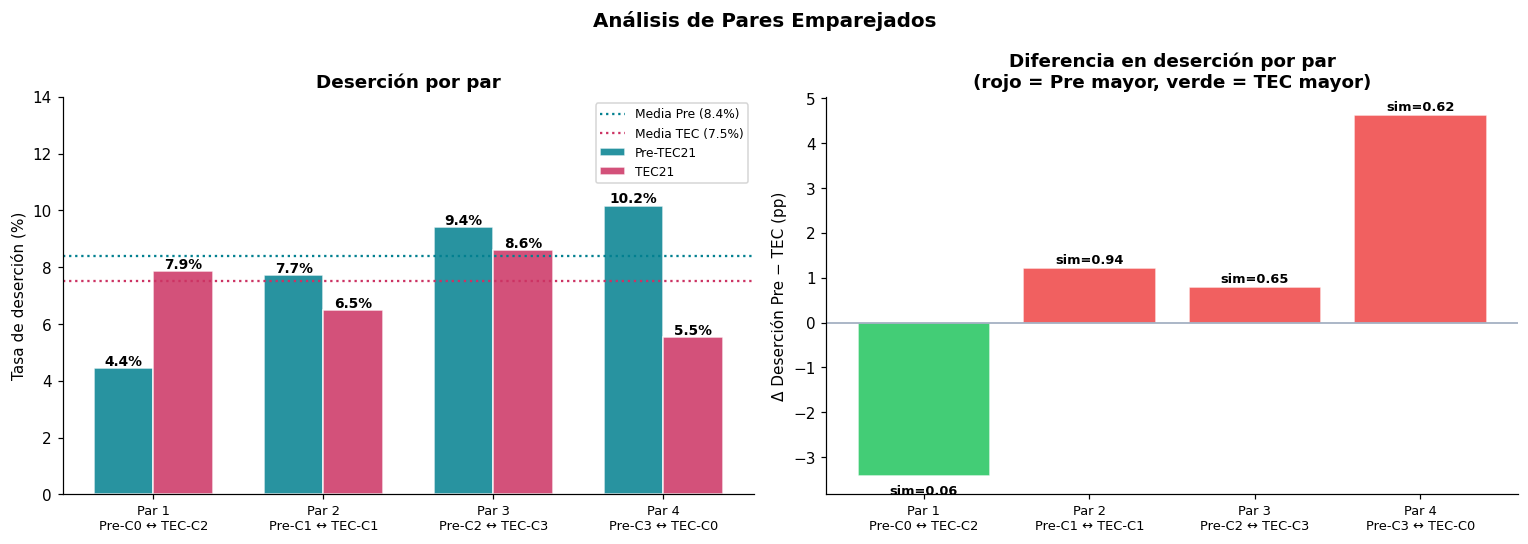

In [32]:
# ── Gráfico comparativo: dropout por par emparejado ────────────────────────
pair_labels = [f'Par {i+1}\nPre-C{r} ↔ TEC-C{c}'
               for i, (r, c, _) in enumerate(match_pairs)]
drop_pre_m  = [y_pre[lbl_pre == r].mean() * 100 for r, c, _ in match_pairs]
drop_tec_m  = [y_tec[lbl_tec == c].mean() * 100 for r, c, _ in match_pairs]
sim_vals    = [s for _, _, s in match_pairs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de Pares Emparejados', fontweight='bold', fontsize=13)

# Barras de deserción
x = np.arange(K); w = 0.35
b1 = ax1.bar(x - w/2, drop_pre_m, w, color='#028090', alpha=0.85,
             edgecolor='white', label='Pre-TEC21')
b2 = ax1.bar(x + w/2, drop_tec_m, w, color='#cc3363', alpha=0.85,
             edgecolor='white', label='TEC21')
for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
ax1.axhline(y_pre.mean()*100, color='#028090', ls=':', lw=1.5,
            label=f'Media Pre ({y_pre.mean()*100:.1f}%)')
ax1.axhline(y_tec.mean()*100, color='#cc3363', ls=':', lw=1.5,
            label=f'Media TEC ({y_tec.mean()*100:.1f}%)')
ax1.set_xticks(x); ax1.set_xticklabels(pair_labels, fontsize=8.5)
ax1.set_ylabel('Tasa de deserción (%)')
ax1.set_title('Deserción por par', fontweight='bold')
ax1.set_ylim(0, 14); ax1.legend(fontsize=8)

# Delta de deserción y similitud
deltas = [p - t for p, t in zip(drop_pre_m, drop_tec_m)]
bar_colors = ['#22c55e' if d < 0 else '#ef4444' for d in deltas]
bars = ax2.bar(x, deltas, color=bar_colors, alpha=0.85, edgecolor='white')
for bar, sim_v in zip(bars, sim_vals):
    ypos = bar.get_height() if bar.get_height() >= 0 else bar.get_height() - 0.5
    ax2.text(bar.get_x() + bar.get_width()/2, ypos + 0.1,
             f'sim={sim_v:.2f}', ha='center', fontsize=8.5, fontweight='bold')
ax2.axhline(0, color='#94a3b8', lw=1)
ax2.set_xticks(x); ax2.set_xticklabels(pair_labels, fontsize=8.5)
ax2.set_ylabel('Δ Deserción Pre − TEC (pp)')
ax2.set_title('Diferencia en deserción por par\n(rojo = Pre mayor, verde = TEC mayor)',
               fontweight='bold')

plt.tight_layout()
plt.savefig('../data/v2_dropout_pares.png', dpi=150, bbox_inches='tight')
plt.show()